Starting extraction...
Extraction complete. Tracked object across 61 frames.


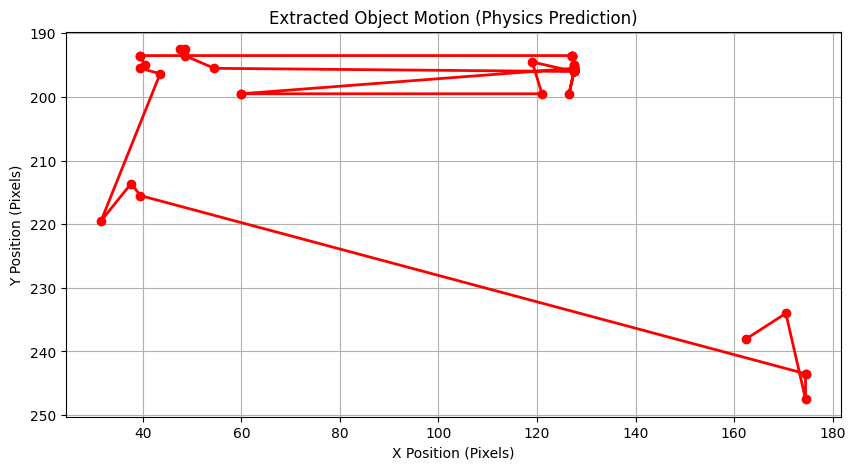

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video_path = "download.mp4"
cap = cv2.VideoCapture(video_path)

x_coords = []
y_coords = []

frame_count = 0

print("Starting extraction...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # 1. Convert to HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 2. Detect RED (The Ball)
    # Red is at both ends of the HSV spectrum (0-10 and 170-180)
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([180, 255, 255])

    mask = cv2.inRange(hsv, lower_red1, upper_red1) + cv2.inRange(hsv, lower_red2, upper_red2)

    # Clean up noise
    mask = cv2.erode(mask, None, iterations=2)
    mask = cv2.dilate(mask, None, iterations=2)

    # 3. Find Center
    contours, _ = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        # Assume largest red blob is the ball
        c = max(contours, key=cv2.contourArea)
        ((x, y), radius) = cv2.minEnclosingCircle(c)

        # Only take it if it's actually a ball (radius > 5 pixels)
        if radius > 5:
            x_coords.append(x)
            y_coords.append(y)
            frame_count += 1

cap.release()

# 4. Results
print(f"Extraction complete. Tracked object across {frame_count} frames.")

# Plot trajectory
plt.figure(figsize=(10, 5))
plt.plot(x_coords, y_coords, 'ro-', linewidth=2, label="Ball Trajectory")
plt.title("Extracted Object Motion (Physics Prediction)")
plt.xlabel("X Position (Pixels)")
plt.ylabel("Y Position (Pixels)")
plt.gca().invert_yaxis() # Image coordinates match video
plt.grid(True)
plt.savefig("final_extraction_plot.png")
plt.show()